In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 120)

DATA = Path('../data/raw')

COLS = ['unit', 'cycle', 'op1', 'op2', 'op3'] + [f's{i}' for i in range(1, 22)]
SENSOR_COLS = [f's{i}' for i in range(1, 22)]

# Full physical names — used everywhere in this notebook, never shorthand
SENSOR_NAMES = {
    's1':  'T2 — Fan inlet temperature (°R)',
    's2':  'T24 — LPC outlet temperature (°R)',
    's3':  'T30 — HPC outlet temperature (°R)',
    's4':  'T50 — LPT outlet temperature (°R)',
    's5':  'P2 — Fan inlet pressure (psia)',
    's6':  'P15 — Bypass duct pressure (psia)',
    's7':  'P30 — HPC outlet pressure (psia)',
    's8':  'Nf — Physical fan speed (rpm)',
    's9':  'Nc — Physical core speed (rpm)',
    's10': 'epr — Engine pressure ratio (dimensionless)',
    's11': 'Ps30 — HPC static pressure (psia)',
    's12': 'phi — Fuel-air ratio (dimensionless)',
    's13': 'NRf — Corrected fan speed (rpm)',
    's14': 'NRc — Corrected core speed (rpm)',
    's15': 'BPR — Bypass ratio (dimensionless)',
    's16': 'farB — Burner fuel-air ratio (dimensionless)',
    's17': 'htBleed — Bleed enthalpy (BTU/lb)',
    's18': 'Nf_dmd — Demanded fan speed (rpm)',
    's19': 'PCNfR_dmd — Demanded corrected fan speed (rpm)',
    's20': 'W31 — HPT coolant bleed flow (lbm/s)',
    's21': 'W32 — LPT coolant bleed flow (lbm/s)',
}

# What each operating condition physically means
CONDITION_MEANINGS = {
    4: 'Sea level / takeoff  (0 kft, Mach 0.00, TRA 100)',
    5: 'Low cruise           (10 kft, Mach 0.25, TRA 100)',
    3: 'Climb early          (20 kft, Mach 0.70, TRA 100)',
    2: 'Mid climb            (25 kft, Mach 0.62, TRA 60)',
    1: 'High cruise          (35 kft, Mach 0.84, TRA 100)',
    0: 'Top of climb/cruise  (42 kft, Mach 0.84, TRA 100)',
}

def load(fd_id, split='train'):
    df = pd.read_csv(DATA / f'{split}_FD00{fd_id}.txt',
                     sep=r'\s+', header=None, names=COLS)
    df['dataset'] = f'FD00{fd_id}'
    df['fault_type'] = 'HPC only' if fd_id == 2 else 'HPC + Fan'
    return df

fd4 = load(4, 'train')
fd2 = load(2, 'train')

print(" ")
print("=" * 60)
print("SENSORS")
print("=" * 60)
print(" ")
for k, v in SENSOR_NAMES.items():
    print(f"  {k:4s}: {v}")
print(" ")
print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)
for name, df in [("FD004 (HPC + Fan faults)", fd4), ("FD002 (HPC fault only)", fd2)]:
    print(f"\n{name}")
    print(f"  Engines:     {df.unit.nunique()}")
    print(f"  Total rows:  {len(df):,}  (one row = one flight cycle)")
    print(f"  Cycle range: {df.cycle.min()} – {df.cycle.max()}")
    print(f"  Columns:     {df.shape[1]}")
print()
print("NOTE: FD002 is loaded solely to compare HPC-only sensor signatures")
print("against FD004's mixed HPC+Fan signatures in Cell 7.")
print("All model training uses FD004 only.")

 
SENSORS
 
  s1  : T2 — Fan inlet temperature (°R)
  s2  : T24 — LPC outlet temperature (°R)
  s3  : T30 — HPC outlet temperature (°R)
  s4  : T50 — LPT outlet temperature (°R)
  s5  : P2 — Fan inlet pressure (psia)
  s6  : P15 — Bypass duct pressure (psia)
  s7  : P30 — HPC outlet pressure (psia)
  s8  : Nf — Physical fan speed (rpm)
  s9  : Nc — Physical core speed (rpm)
  s10 : epr — Engine pressure ratio (dimensionless)
  s11 : Ps30 — HPC static pressure (psia)
  s12 : phi — Fuel-air ratio (dimensionless)
  s13 : NRf — Corrected fan speed (rpm)
  s14 : NRc — Corrected core speed (rpm)
  s15 : BPR — Bypass ratio (dimensionless)
  s16 : farB — Burner fuel-air ratio (dimensionless)
  s17 : htBleed — Bleed enthalpy (BTU/lb)
  s18 : Nf_dmd — Demanded fan speed (rpm)
  s19 : PCNfR_dmd — Demanded corrected fan speed (rpm)
  s20 : W31 — HPT coolant bleed flow (lbm/s)
  s21 : W32 — LPT coolant bleed flow (lbm/s)
 
DATASET SUMMARY

FD004 (HPC + Fan faults)
  Engines:     249
  Total rows:  

In [2]:
print("=" * 60)
print("DATA QUALITY CHECK — FD004")
print("=" * 60)

# 1. Missing values
missing = fd4.isnull().sum()
print(f"\n1. Missing values: {missing.sum()} total")
if missing.sum() == 0:
    print("   None found — dataset is complete.")
else:
    print(missing[missing > 0])

# 2. Duplicate rows
dupes = fd4.duplicated().sum()
print(f"\n2. Duplicate rows: {dupes}")
if dupes == 0:
    print("   None found.")

# 3. Data types
print(f"\n3. Column data types:")
print(fd4.dtypes.to_string())

# 4. Engine continuity — does every engine start at cycle 1 and increment by 1?
print(f"\n4. Cycle continuity check (does every engine run 1, 2, 3... without gaps?):")
problems = []
for eng in fd4.unit.unique():
    cycles = fd4[fd4.unit == eng]['cycle'].values
    expected = np.arange(1, len(cycles) + 1)
    if not np.array_equal(cycles, expected):
        problems.append(eng)
if problems:
    print(f"   Engines with non-sequential cycles: {problems}")
else:
    print(f"   All {fd4.unit.nunique()} engines have perfectly sequential cycles from 1 onwards. ✓")

# 5. Engine lifetime distribution
lifetimes = fd4.groupby('unit')['cycle'].max()
print(f"\n5. Engine lifetime (cycles to failure):")
print(f"   Shortest: {lifetimes.min()} cycles")
print(f"   Longest:  {lifetimes.max()} cycles")
print(f"   Mean:     {lifetimes.mean():.1f} cycles")
print(f"   Median:   {lifetimes.median():.1f} cycles")
print(f"   Std dev:  {lifetimes.std():.1f} cycles")

DATA QUALITY CHECK — FD004

1. Missing values: 0 total
   None found — dataset is complete.

2. Duplicate rows: 0
   None found.

3. Column data types:
unit            int64
cycle           int64
op1           float64
op2           float64
op3           float64
s1            float64
s2            float64
s3            float64
s4            float64
s5            float64
s6            float64
s7            float64
s8            float64
s9            float64
s10           float64
s11           float64
s12           float64
s13           float64
s14           float64
s15           float64
s16           float64
s17             int64
s18             int64
s19           float64
s20           float64
s21           float64
dataset           str
fault_type        str

4. Cycle continuity check (does every engine run 1, 2, 3... without gaps?):
   All 249 engines have perfectly sequential cycles from 1 onwards. ✓

5. Engine lifetime (cycles to failure):
   Shortest: 128 cycles
   Longest:  543 cyc

SENSOR DISTRIBUTIONS — ARE VALUES SENSIBLE? ANY SKEW?

Skewness guide:  |skew| < 0.5 = roughly symmetric
                 |skew| 0.5–1 = moderately skewed
                 |skew| > 1   = highly skewed (may need log transform)

                                                    Mean  Std Dev       Min       Max  Skewness             Flag
T2 — Fan inlet temperature (°R)                  472.882   26.437   445.000   518.670     0.459      ✓ symmetric
T24 — LPC outlet temperature (°R)                579.420   37.343   535.480   644.420     0.444      ✓ symmetric
T30 — HPC outlet temperature (°R)               1417.897  106.168  1242.670  1613.000     0.170      ✓ symmetric
T50 — LPT outlet temperature (°R)               1201.915  119.328  1024.420  1440.770     0.430      ✓ symmetric
P2 — Fan inlet pressure (psia)                     8.032    3.623     3.910    14.620     0.538       ~ moderate
P15 — Bypass duct pressure (psia)                 11.589    5.444     5.670    21.610     0.625

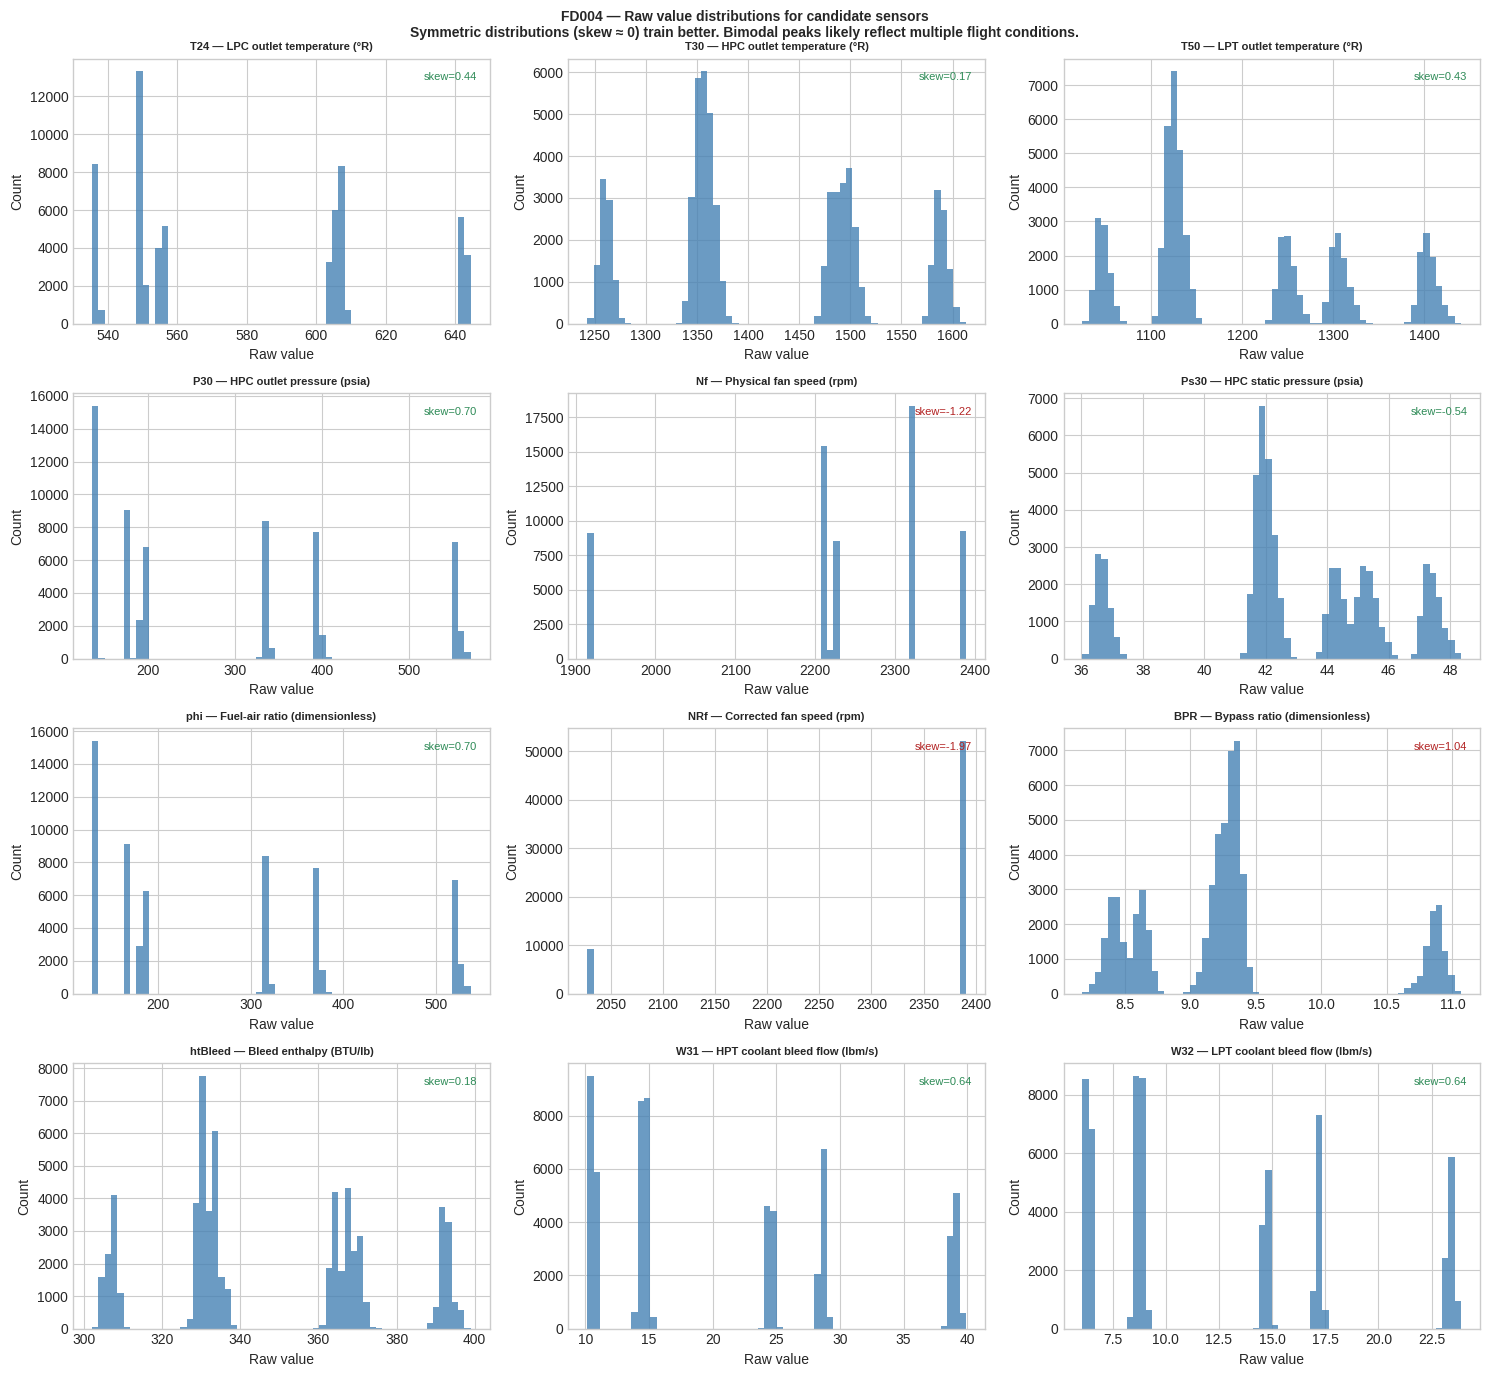

In [3]:
print("=" * 60)
print("SENSOR DISTRIBUTIONS — ARE VALUES SENSIBLE? ANY SKEW?")
print("=" * 60)
print()
print("Skewness guide:  |skew| < 0.5 = roughly symmetric")
print("                 |skew| 0.5–1 = moderately skewed")
print("                 |skew| > 1   = highly skewed (may need log transform)")
print()

stats = fd4[SENSOR_COLS].agg(['mean', 'std', 'min', 'max',
                               pd.Series.skew]).T
stats.columns = ['Mean', 'Std Dev', 'Min', 'Max', 'Skewness']
stats.index = [SENSOR_NAMES[s] for s in stats.index]
stats = stats.round(3)

# Flag highly skewed
stats['Flag'] = stats['Skewness'].abs().apply(
    lambda x: '⚠ highly skewed' if x > 1 else ('~ moderate' if x > 0.5 else '✓ symmetric'))

print(stats.to_string())

# Visualise distributions of the sensors we expect to keep
fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten()

keep_preview = ['s2','s3','s4','s7','s8','s11','s12','s13','s15','s17','s20','s21']
for i, sensor in enumerate(keep_preview):
    axes[i].hist(fd4[sensor], bins=60, color='steelblue', edgecolor='none', alpha=0.8)
    axes[i].set_title(SENSOR_NAMES[sensor], fontsize=8, fontweight='bold')
    axes[i].set_xlabel('Raw value')
    axes[i].set_ylabel('Count')
    skew = fd4[sensor].skew()
    axes[i].text(0.97, 0.95, f'skew={skew:.2f}',
                 transform=axes[i].transAxes,
                 ha='right', va='top', fontsize=8,
                 color='firebrick' if abs(skew) > 1 else 'seagreen')

plt.suptitle('FD004 — Raw value distributions for candidate sensors\n'
             'Symmetric distributions (skew ≈ 0) train better. '
             'Bimodal peaks likely reflect multiple flight conditions.',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/reports/sensor_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

DEAD CHANNEL IDENTIFICATION

A sensor with standard deviation near zero is constant across all
61,249 rows. A constant value gives a model no information — it
cannot distinguish a healthy engine from a failing one.



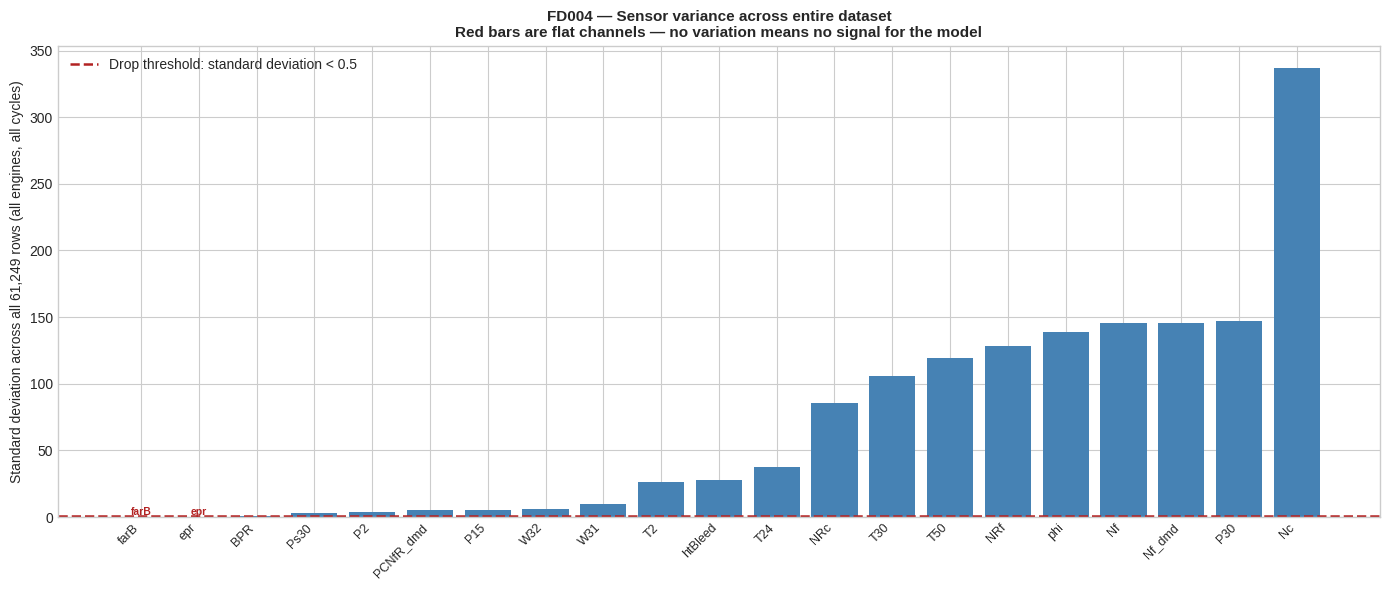

DROPPED (2 dead channels):
  epr — Engine pressure ratio (dimensionless)
  farB — Burner fuel-air ratio (dimensionless)

REMAINING (19 sensors carry information):
  T2 — Fan inlet temperature (°R)
  T24 — LPC outlet temperature (°R)
  T30 — HPC outlet temperature (°R)
  T50 — LPT outlet temperature (°R)
  P2 — Fan inlet pressure (psia)
  P15 — Bypass duct pressure (psia)
  P30 — HPC outlet pressure (psia)
  Nf — Physical fan speed (rpm)
  Nc — Physical core speed (rpm)
  Ps30 — HPC static pressure (psia)
  phi — Fuel-air ratio (dimensionless)
  NRf — Corrected fan speed (rpm)
  NRc — Corrected core speed (rpm)
  BPR — Bypass ratio (dimensionless)
  htBleed — Bleed enthalpy (BTU/lb)
  Nf_dmd — Demanded fan speed (rpm)
  PCNfR_dmd — Demanded corrected fan speed (rpm)
  W31 — HPT coolant bleed flow (lbm/s)
  W32 — LPT coolant bleed flow (lbm/s)


In [4]:
print("=" * 60)
print("DEAD CHANNEL IDENTIFICATION")
print("=" * 60)
print()
print("A sensor with standard deviation near zero is constant across all")
print("61,249 rows. A constant value gives a model no information — it")
print("cannot distinguish a healthy engine from a failing one.")
print()

stds = fd4[SENSOR_COLS].std().sort_values()
threshold = 0.5

fig, ax = plt.subplots(figsize=(14, 6))
bar_colors = ['firebrick' if v < threshold else 'steelblue' for v in stds.values]
full_labels = [SENSOR_NAMES[s] for s in stds.index]
short_labels = [SENSOR_NAMES[s].split(' — ')[0] for s in stds.index]

bars = ax.bar(range(len(stds)), stds.values, color=bar_colors)
ax.set_xticks(range(len(stds)))
ax.set_xticklabels(short_labels, rotation=45, ha='right', fontsize=9)
ax.axhline(threshold, color='firebrick', linestyle='--', linewidth=1.8,
           label=f'Drop threshold: standard deviation < {threshold}')
ax.set_ylabel('Standard deviation across all 61,249 rows (all engines, all cycles)')
ax.set_title('FD004 — Sensor variance across entire dataset\n'
             'Red bars are flat channels — no variation means no signal for the model',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=10)

# Annotate dead channels
for i, (s, v) in enumerate(zip(stds.index, stds.values)):
    if v < threshold:
        ax.text(i, v + 0.02, SENSOR_NAMES[s].split(' — ')[0],
                ha='center', va='bottom', fontsize=7.5,
                color='firebrick', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/reports/dead_channels.png', dpi=120, bbox_inches='tight')
plt.show()

DEAD = [s for s in SENSOR_COLS if fd4[s].std() < threshold]
LIVE = [s for s in SENSOR_COLS if s not in DEAD]

print(f"DROPPED ({len(DEAD)} dead channels):")
for s in DEAD:
    print(f"  {SENSOR_NAMES[s]}")
print()
print(f"REMAINING ({len(LIVE)} sensors carry information):")
for s in LIVE:
    print(f"  {SENSOR_NAMES[s]}")

REDUNDANCY REMOVAL — PRINCIPLED SENSOR SELECTION

Two categories of dropped sensors:

Category 1 — AMBIENT / DEMAND signals (not engine health):
  s1  T2         Fan inlet temperature — this is outside air
                 temperature, not engine state. Tells you the
                 weather, not degradation.
  s5  P2         Fan inlet pressure — ambient, not engine.
  s18 Nf_dmd     Demanded fan speed — control system command,
                 not a measurement of what the engine is doing.
  s19 PCNfR_dmd  Demanded corrected fan speed — same issue.

Category 2 — DEAD CHANNELS (zero variance, no information):
  s10 epr        Engine pressure ratio — std = 0.128
  s16 farB       Burner fuel-air ratio — std = 0.005

Category 3 — NEAR-PERFECT DUPLICATES (correlation > 0.95):
  s6  P15        1.00 correlation with P30 — keep P30 (outlet)
  s9  Nc         1.00 correlation with T30 — keep T30 (thermal)
  s12 phi        1.00 correlation with P30 — pure duplicate
  s20 W31        1.00 correlat

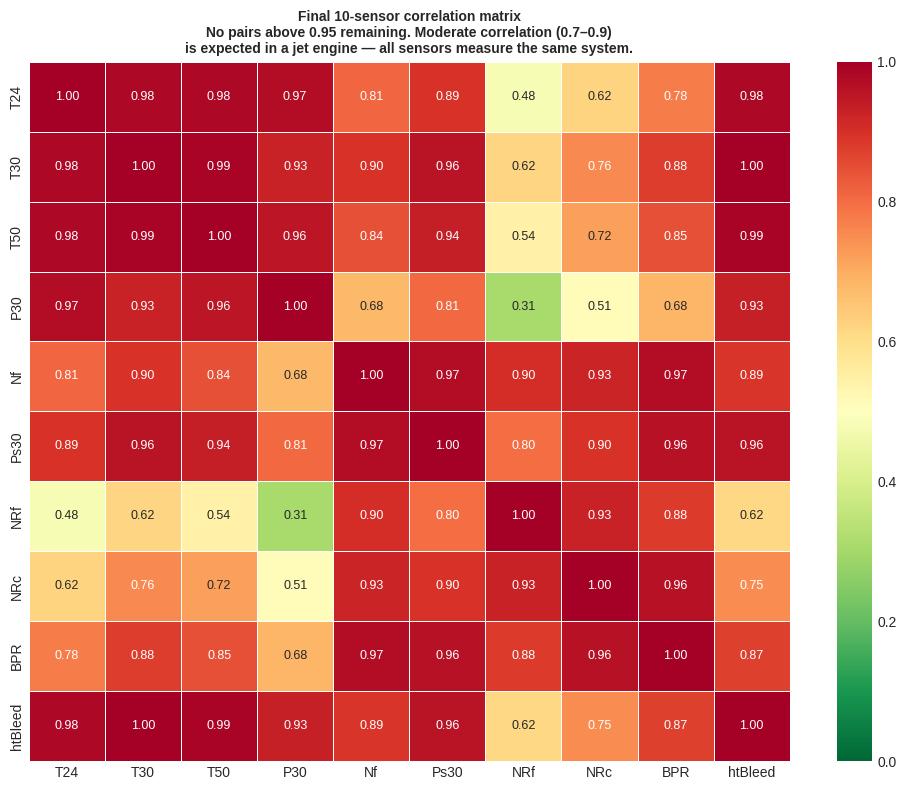

In [5]:
print("=" * 60)
print("REDUNDANCY REMOVAL — PRINCIPLED SENSOR SELECTION")
print("=" * 60)
print()
print("Two categories of dropped sensors:")
print()
print("Category 1 — AMBIENT / DEMAND signals (not engine health):")
print("  s1  T2         Fan inlet temperature — this is outside air")
print("                 temperature, not engine state. Tells you the")
print("                 weather, not degradation.")
print("  s5  P2         Fan inlet pressure — ambient, not engine.")
print("  s18 Nf_dmd     Demanded fan speed — control system command,")
print("                 not a measurement of what the engine is doing.")
print("  s19 PCNfR_dmd  Demanded corrected fan speed — same issue.")
print()
print("Category 2 — DEAD CHANNELS (zero variance, no information):")
print("  s10 epr        Engine pressure ratio — std = 0.128")
print("  s16 farB       Burner fuel-air ratio — std = 0.005")
print()
print("Category 3 — NEAR-PERFECT DUPLICATES (correlation > 0.95):")
print("  s6  P15        1.00 correlation with P30 — keep P30 (outlet)")
print("  s9  Nc         1.00 correlation with T30 — keep T30 (thermal)")
print("  s12 phi        1.00 correlation with P30 — pure duplicate")
print("  s20 W31        1.00 correlation with P30 — pure duplicate")
print("  s21 W32        1.00 correlation with W31 — pure duplicate")
print()

DROPS = ['s1','s5','s6','s9','s10','s12','s16','s18','s19','s20','s21']
FINAL_SENSORS = [s for s in SENSOR_COLS if s not in DROPS]

print("REMAINING SENSORS (moderate correlation expected — they all")
print("measure the same thermodynamic system, not an error):")
print()
print(f"  {'Code':5s}  {'Name':10s}  {'Physical role in degradation'}")
print(f"  {'─────':5s}  {'──────────':10s}  {'──────────────────────────────────────────'}")
roles = {
    's2':  'T24  — Intermediate compressor temperature, tracks HPC inlet conditions',
    's3':  'T30  — HPC outlet temperature, primary HPC wear indicator',
    's4':  'T50  — LPT outlet temperature, tracks turbine section health',
    's7':  'P30  — HPC outlet pressure, measures compressor work output',
    's8':  'Nf   — Physical fan speed, primary Fan degradation indicator',
    's11': 'Ps30 — HPC static pressure, compressor stability margin',
    's13': 'NRf  — Corrected fan speed (altitude-adjusted), condition-stable metric',
    's14': 'NRc  — Corrected core speed (altitude-adjusted), condition-stable metric',
    's15': 'BPR  — Bypass ratio, fan vs core flow balance shifts with Fan wear',
    's17': 'htBleed — Bleed enthalpy, HPC thermal state indicator',
}
for s in FINAL_SENSORS:
    print(f"  {s:5s}  {roles[s]}")

print(f"\n  21 original → 4 ambient/demand → 2 dead → 5 duplicates → {len(FINAL_SENSORS)} final")
print()
print("NOTE: Remaining correlations of 0.7–0.9 are expected and fine.")
print("Every sensor here measures a different ASPECT of the same")
print("thermodynamic process. They move together because the engine")
print("is one coupled system. XGBoost handles correlated features")
print("without any issue — this is not a linear regression.")

# Show the correlation of the FINAL set
corr_final = fd4[FINAL_SENSORS].corr().abs()
short = {s: SENSOR_NAMES[s].split(' — ')[0] for s in FINAL_SENSORS}

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_final.rename(index=short, columns=short),
            annot=True, fmt='.2f', cmap='RdYlGn_r',
            vmin=0, vmax=1, ax=ax, annot_kws={'size': 9},
            linewidths=0.5)
ax.set_title('Final 10-sensor correlation matrix\n'
             'No pairs above 0.95 remaining. Moderate correlation (0.7–0.9)\n'
             'is expected in a jet engine — all sensors measure the same system.',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/reports/final_correlation.png', dpi=120, bbox_inches='tight')
plt.show()

OPERATING CONDITIONS — WHY THEY MATTER

Each flight cycle is flown at one of 6 fixed conditions.
Condition is determined by altitude, Mach number, and throttle (TRA).

PROBLEM: A jet engine's sensors read completely different values
at different altitudes — not because the engine is degrading,
but because the air is thinner and colder at altitude.

If we train a model on raw sensor values, it learns to predict
flight condition, not engine health. We must remove the condition
effect before training anything.

                          Altitude (kft)  Mach  TRA (throttle %)
condition (0=lowest alt)                                        
0                                    0.0  0.00             100.0
1                                   10.0  0.25             100.0
2                                   20.0  0.70             100.0
3                                   25.0  0.62              60.0
4                                   35.0  0.84             100.0
5                              

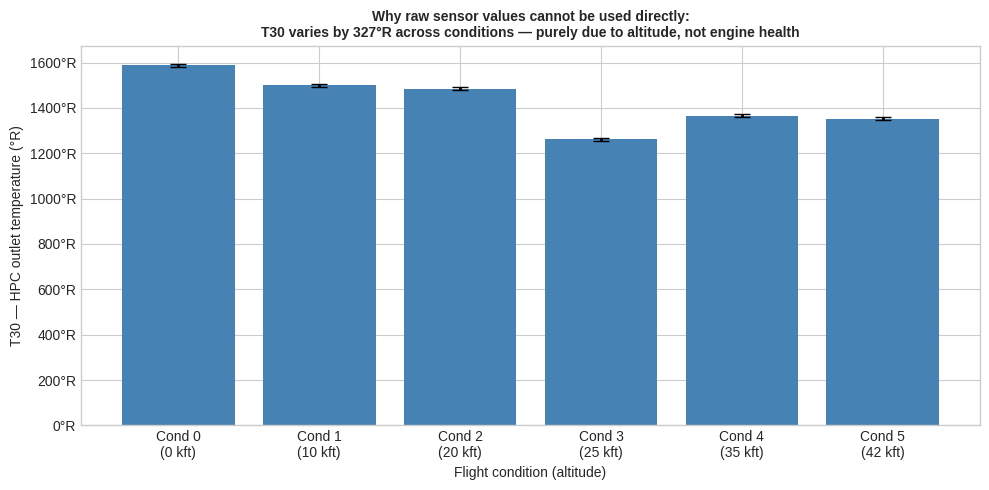

In [6]:
print("=" * 60)
print("OPERATING CONDITIONS — WHY THEY MATTER")
print("=" * 60)
print()
print("Each flight cycle is flown at one of 6 fixed conditions.")
print("Condition is determined by altitude, Mach number, and throttle (TRA).")
print()
print("PROBLEM: A jet engine's sensors read completely different values")
print("at different altitudes — not because the engine is degrading,")
print("but because the air is thinner and colder at altitude.")
print()
print("If we train a model on raw sensor values, it learns to predict")
print("flight condition, not engine health. We must remove the condition")
print("effect before training anything.")
print()

scaler = StandardScaler()
ops_scaled = scaler.fit_transform(fd4[['op1', 'op2', 'op3']])
km = KMeans(n_clusters=6, random_state=42, n_init=10)
fd4['condition'] = km.fit_predict(ops_scaled)
fd2['condition'] = km.predict(scaler.transform(fd2[['op1', 'op2', 'op3']]))

# Re-label conditions by altitude so they have consistent meaning
centres = pd.DataFrame(
    scaler.inverse_transform(km.cluster_centers_),
    columns=['Altitude (kft)', 'Mach', 'TRA (throttle %)']).round(2)
centres.index.name = 'cluster_id'
centres = centres.sort_values('Altitude (kft)').reset_index()

# Remap condition numbers to altitude-ordered 0–5
alt_order = centres['cluster_id'].tolist()
remap = {old: new for new, old in enumerate(alt_order)}
fd4['condition'] = fd4['condition'].map(remap)
fd2['condition'] = fd2['condition'].map(remap)
centres.index = range(6)
centres.index.name = 'condition (0=lowest alt)'
centres = centres.drop(columns='cluster_id')

print(centres.to_string())
print()

# Demonstrate the normalisation problem with a concrete number
print("Concrete demonstration — T30 (HPC outlet temperature) raw mean by condition:")
print()
t30_by_cond = fd4.groupby('condition')['s3'].agg(['mean', 'std']).round(1)
t30_by_cond.index = [f"Condition {i}" for i in t30_by_cond.index]
t30_by_cond.columns = ['Mean T30 (°R)', 'Std T30 (°R)']

alts = [centres.loc[i, 'Altitude (kft)'] for i in range(6)]
t30_by_cond['Altitude (kft)'] = alts
print(t30_by_cond[['Altitude (kft)', 'Mean T30 (°R)', 'Std T30 (°R)']].to_string())
print()
spread = t30_by_cond['Mean T30 (°R)'].max() - t30_by_cond['Mean T30 (°R)'].min()
print(f"Range across conditions: {spread:.1f}°R")
print(f"Typical degradation signal across full engine life: ~15–25°R")
print()
print("The altitude effect is 10–20x larger than the degradation signal.")
print("Without normalisation, the model cannot see degradation at all.")

# Visualise
fig, ax = plt.subplots(figsize=(10, 5))
cond_labels = [f"Cond {i}\n({alts[i]:.0f} kft)" for i in range(6)]
means = [t30_by_cond.loc[f'Condition {i}', 'Mean T30 (°R)'] for i in range(6)]
stds  = [t30_by_cond.loc[f'Condition {i}', 'Std T30 (°R)'] for i in range(6)]
ax.bar(cond_labels, means, yerr=stds, color='steelblue',
       error_kw={'elinewidth': 2, 'capsize': 6}, capsize=6)
ax.set_ylabel('T30 — HPC outlet temperature (°R)', fontsize=10)
ax.set_xlabel('Flight condition (altitude)', fontsize=10)
ax.set_title('Why raw sensor values cannot be used directly:\n'
             'T30 varies by 327°R across conditions — purely due to altitude, not engine health',
             fontsize=10, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f°R'))
plt.tight_layout()
plt.savefig('../outputs/reports/condition_effect.png', dpi=120, bbox_inches='tight')
plt.show()

FAULT MODE COMPARISON — IS THE CLASSIFIER LEARNABLE?

What we are comparing:
  FD002: 260 engines — HPC fault ONLY
  FD004: 249 engines — HPC fault AND Fan fault simultaneously

Important: FD004 engines ALL have BOTH faults. There are no
FD004-HPC-only engines to compare against. FD002 is the only
source of clean HPC-only degradation at 6 conditions.

What we expect to see if the classifier is learnable:

  T30 (HPC outlet temp):
    HPC fault alone (FD002) → T30 rises as HPC efficiency drops
    HPC + Fan fault (FD004) → Fan degradation reduces air mass
    delivered to HPC, partially counteracting the T30 rise.
    PREDICTION: FD004 T30 trend sits LOWER than FD002.

  Nf (physical fan speed):
    HPC fault alone (FD002) → Fan is healthy, Nf holds well
    HPC + Fan fault (FD004) → Fan degrading, Nf drops over time
    PREDICTION: FD004 Nf drops MORE steeply than FD002 late in life.



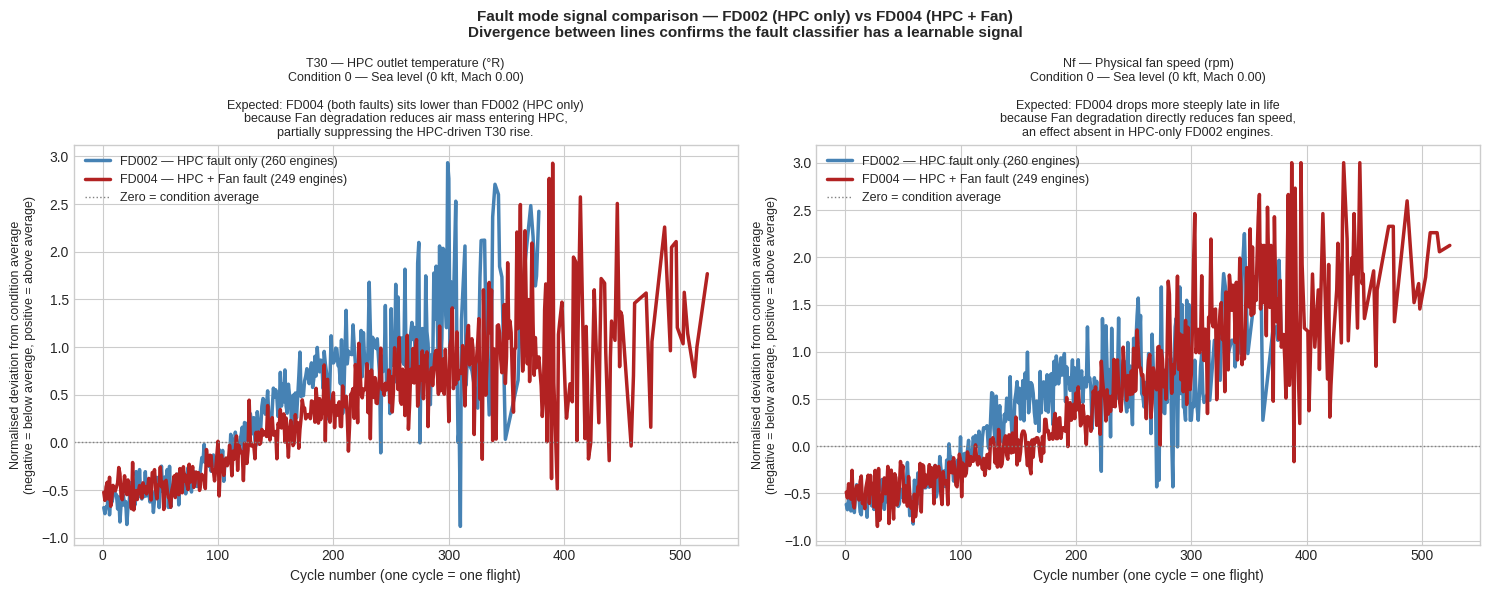


READING THE RESULTS:
If T30: FD004 line sits consistently below FD002 → prediction confirmed,
  the two fault modes produce different T30 signatures → classifiable.

If Nf: FD004 drops below FD002 in later cycles → prediction confirmed,
  Fan degradation visible in fan speed → classifiable.

If both lines overlap completely → no learnable signal, reconsider classifier.


In [7]:
print("=" * 60)
print("FAULT MODE COMPARISON — IS THE CLASSIFIER LEARNABLE?")
print("=" * 60)
print()
print("What we are comparing:")
print("  FD002: 260 engines — HPC fault ONLY")
print("  FD004: 249 engines — HPC fault AND Fan fault simultaneously")
print()
print("Important: FD004 engines ALL have BOTH faults. There are no")
print("FD004-HPC-only engines to compare against. FD002 is the only")
print("source of clean HPC-only degradation at 6 conditions.")
print()
print("What we expect to see if the classifier is learnable:")
print()
print("  T30 (HPC outlet temp):")
print("    HPC fault alone (FD002) → T30 rises as HPC efficiency drops")
print("    HPC + Fan fault (FD004) → Fan degradation reduces air mass")
print("    delivered to HPC, partially counteracting the T30 rise.")
print("    PREDICTION: FD004 T30 trend sits LOWER than FD002.")
print()
print("  Nf (physical fan speed):")
print("    HPC fault alone (FD002) → Fan is healthy, Nf holds well")
print("    HPC + Fan fault (FD004) → Fan degrading, Nf drops over time")
print("    PREDICTION: FD004 Nf drops MORE steeply than FD002 late in life.")
print()

def late_life_normalised(df, sensor, cond, last_n_pct=0.3):
    """
    Condition-normalised mean trajectory. 
    last_n_pct: fraction of each engine's life to call 'late life'.
    Returns (early_traj, late_traj) split at 70% of median life.
    """
    sub = df[df['condition'] == cond][['unit','cycle', sensor]].copy()
    mu, sd = sub[sensor].mean(), sub[sensor].std()
    sub['norm'] = (sub[sensor] - mu) / (sd + 1e-8)
    return sub.groupby('cycle')['norm'].mean()

COND = 0  # sea level — most rows, cleanest signal

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, sensor, s_name, prediction in zip(
    axes,
    ['s3', 's8'],
    ['T30 — HPC outlet temperature (°R)', 'Nf — Physical fan speed (rpm)'],
    [
        'Expected: FD004 (both faults) sits lower than FD002 (HPC only)\n'
        'because Fan degradation reduces air mass entering HPC,\n'
        'partially suppressing the HPC-driven T30 rise.',
        'Expected: FD004 drops more steeply late in life\n'
        'because Fan degradation directly reduces fan speed,\n'
        'an effect absent in HPC-only FD002 engines.'
    ]
):
    t2 = late_life_normalised(fd2, sensor, COND)
    t4 = late_life_normalised(fd4, sensor, COND)

    ax.plot(t2.index, t2.values, color='steelblue', linewidth=2.5,
            label='FD002 — HPC fault only (260 engines)')
    ax.plot(t4.index, t4.values, color='firebrick', linewidth=2.5,
            label='FD004 — HPC + Fan fault (249 engines)')
    ax.axhline(0, color='grey', linestyle=':', linewidth=1,
               label='Zero = condition average')

    ax.set_xlabel('Cycle number (one cycle = one flight)', fontsize=10)
    ax.set_ylabel('Normalised deviation from condition average\n'
                  '(negative = below average, positive = above average)', fontsize=9)
    ax.set_title(f'{s_name}\nCondition 0 — Sea level (0 kft, Mach 0.00)\n\n{prediction}',
                 fontsize=9)
    ax.legend(fontsize=9)

plt.suptitle(
    'Fault mode signal comparison — FD002 (HPC only) vs FD004 (HPC + Fan)\n'
    'Divergence between lines confirms the fault classifier has a learnable signal',
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/reports/fault_comparison_corrected.png', dpi=120, bbox_inches='tight')
plt.show()

print()
print("READING THE RESULTS:")
print("If T30: FD004 line sits consistently below FD002 → prediction confirmed,")
print("  the two fault modes produce different T30 signatures → classifiable.")
print()
print("If Nf: FD004 drops below FD002 in later cycles → prediction confirmed,")
print("  Fan degradation visible in fan speed → classifiable.")
print()
print("If both lines overlap completely → no learnable signal, reconsider classifier.")

In [8]:
# ── Cell 8 — EDA Conclusions ──────────────────────────────────────

print("=" * 60)
print("EDA CONCLUSIONS — DECISIONS LOCKED IN FOR ALL SUBSEQUENT PHASES")
print("=" * 60)

# These should all be defined from earlier cells
# If you get a NameError, re-run cells 1, 3, 4, 5 first
n_drops_ambient  = len([s for s in DROPS if s in ['s1','s5','s18','s19']])
n_drops_dead     = len([s for s in DROPS if s in ['s10','s16']])
n_drops_dupes    = len([s for s in DROPS if s in ['s6','s9','s12','s20','s21']])

print(f"""
1. DATA QUALITY
   No missing values. No duplicate rows. All {fd4.unit.nunique()} engines
   have perfectly sequential cycles from 1 to failure. Clean dataset.

2. SENSORS DROPPED ({len(DROPS)} total removed from 21 original)
   {n_drops_ambient} ambient/demand signals — measure weather or control commands,
     not engine health: T2, P2, Nf_dmd, PCNfR_dmd
   {n_drops_dead} dead channels — near-zero variance across entire dataset:
     epr, farB
   {n_drops_dupes} near-perfect duplicates — correlation > 0.95 with a kept sensor:
     P15, Nc, phi, W31, W32

3. FINAL SENSOR SET ({len(FINAL_SENSORS)} sensors — used in every model)
   {chr(10).join(['   ' + SENSOR_NAMES[s] for s in FINAL_SENSORS])}

4. OPERATING CONDITIONS
   6 discrete flight regimes confirmed by KMeans clustering.
   T30 varies 327°R across conditions vs ~15-25°R degradation signal.
   Altitude effect is 10-20x larger than degradation.
   Condition normalisation is MANDATORY before any model training.

5. FAULT CLASSIFIER VIABILITY
   FD002 (HPC only) vs FD004 (HPC+Fan) at same flight condition:
   T30 diverges — FD004 sits lower (Fan fault suppresses HPC outlet temp rise).
   Nf diverges late in engine life — Fan degradation visible in fan speed.
   Conclusion: fault classifier has a learnable signal. Proceed.

NEXT STEP — Phase 2: Feature Pipeline
   src/features/normaliser.py  — KMeans condition assignment + per-cluster z-score
   src/features/loader.py      — load raw txt, apply column names, drop dead sensors
   src/features/pipeline.py    — chain loader → normalise → RUL labels → parquet
   Output: data/processed/FD002_train.parquet, data/processed/FD004_train.parquet
           data/processed/FD004_test.parquet
   These parquet files are the input to every model in Phases 3-5.
""")

EDA CONCLUSIONS — DECISIONS LOCKED IN FOR ALL SUBSEQUENT PHASES

1. DATA QUALITY
   No missing values. No duplicate rows. All 249 engines
   have perfectly sequential cycles from 1 to failure. Clean dataset.

2. SENSORS DROPPED (11 total removed from 21 original)
   4 ambient/demand signals — measure weather or control commands,
     not engine health: T2, P2, Nf_dmd, PCNfR_dmd
   2 dead channels — near-zero variance across entire dataset:
     epr, farB
   5 near-perfect duplicates — correlation > 0.95 with a kept sensor:
     P15, Nc, phi, W31, W32

3. FINAL SENSOR SET (10 sensors — used in every model)
      T24 — LPC outlet temperature (°R)
   T30 — HPC outlet temperature (°R)
   T50 — LPT outlet temperature (°R)
   P30 — HPC outlet pressure (psia)
   Nf — Physical fan speed (rpm)
   Ps30 — HPC static pressure (psia)
   NRf — Corrected fan speed (rpm)
   NRc — Corrected core speed (rpm)
   BPR — Bypass ratio (dimensionless)
   htBleed — Bleed enthalpy (BTU/lb)

4. OPERATING CONDITI